# MedSeg 全流程测试 — VOC2012 数据集

本 Notebook 以 Pascal VOC 2012 为测试数据集，跑通 MedSeg 完整链路：

1. **数据集导入** — 每个 VOC 类别导入 10 张图像（含专家标注掩码）到 RAG 索引
2. **RAG 检索** — 输入查询图片，DINOv3 + FAISS 返回 Top-k 相似样例
3. **SAM3 memory bank 分割** — 将检索样例写入 memory bank 后锁定，对目标帧推理

## 前置准备
- 下载 [Pascal VOC 2012](http://host.robots.ox.ac.uk/pascal/VOC/voc2012/) 数据集并解压
- 准备 SAM3 模型权重文件
- GPU/CUDA 环境可用

## 0. 配置参数

修改以下路径和设备 ID 为你本机的实际值后运行。

In [8]:
# ========================== 路径配置 ==========================
VOC2012_ROOT      = "/home/homesdb/zichengl/.cache/kagglehub/datasets/gopalbhattrai/pascal-voc-2012-dataset/versions/1/VOC2012_train_val/VOC2012_train_val/"             # VOC2012 根目录（含 JPEGImages/SegmentationClass）
SAM3_CKPT         = "/home/homesdb/zichengl/medseg/testblock/sam3/checkpoints/sam3.pt"    # SAM3 模型权重
SAM3_VERSION      = "sam3"                          # "sam3" 或 "sam3.1"
RAG_INDEX_DIR     = "./voc2012_rag_index"             # RAG 索引持久化目录
DINOV3_MODEL_NAME = "facebook/dinov3-vith16plus-pretrain-lvd1689m"                              # HF repo id，None 使用默认 facebook/dinov3-vitl16
                                                      # 如 "facebook/dinov3-vith16plus-pretrain-lvd1689m"

# ========================== GPU 配置 ==========================
CUDA_RAG = 0   # RAG 系统 (DINOv3 embedder) 使用的 CUDA 设备
CUDA_SAM = 0   # SAM3 分割器使用的 CUDA 设备

# ========================== 离线/在线 ==========================
HF_OFFLINE = True  # 无外网时设为 True（需提前下载模型到 HF cache）

# ========================== 分割参数 ==========================
TOP_K              = 5      # RAG 检索 top-k
IMAGES_PER_CLASS   = 10     # 每类别导入图像数
OUTPUT_PROB_THRESH = 0.5    # 二值化阈值
LOCK_MEMORY        = True   # 是否锁定 memory bank
QUERY_IMAGE_PATH   = None   # 设为 None 则从导入数据中自动选取一张作为查询图

import os, sys, random, warnings
from pathlib import Path

warnings.filterwarnings("ignore", message=".*IProgress.*")

assert Path(VOC2012_ROOT).is_dir(), f"VOC2012 目录不存在: {VOC2012_ROOT}"

# VOC 全部 20 个前景类别
VOC_CLASSES = [
    "aeroplane", "bicycle", "bird", "boat", "bottle",
    "bus", "car", "cat", "chair", "cow",
    "diningtable", "dog", "horse", "motorbike", "person",
    "pottedplant", "sheep", "sofa", "train", "tvmonitor",
]

print(f"VOC2012 root : {VOC2012_ROOT}")
print(f"DINOv3 model : {DINOV3_MODEL_NAME or 'facebook/dinov3-vitl16 (default)'}")
print(f"CUDA device  : RAG={CUDA_RAG}, SAM={CUDA_SAM}")
print(f"SAM3 version : {SAM3_VERSION}")
print(f"RAG index    : {RAG_INDEX_DIR}")
print(f"HF offline   : {HF_OFFLINE}")
print(f"Per class    : {IMAGES_PER_CLASS} images, {len(VOC_CLASSES)} classes")

VOC2012 root : /home/homesdb/zichengl/.cache/kagglehub/datasets/gopalbhattrai/pascal-voc-2012-dataset/versions/1/VOC2012_train_val/VOC2012_train_val/
DINOv3 model : facebook/dinov3-vith16plus-pretrain-lvd1689m
CUDA device  : RAG=0, SAM=0
SAM3 version : sam3
RAG index    : ./voc2012_rag_index
HF offline   : True
Per class    : 10 images, 20 classes


## 1. 数据集导入 — 每类别 10 张写入 RAG 索引

使用 `VOCImporter` 按类别发现 image-mask 配对，每类随机采样 10 张，通过 `RAGSystem.index_images()` 批量写入索引。

**类别级 mask**：`VOCImporter` 的 `class_name` 参数会自动将 VOC 调色板 mask 转换为该类的二值 PNG（0/255），与 SAM3 的 mask 输入格式对齐。

In [ ]:
from rag import RAGSystem
from rag.dataset_importers import VOCImporter

os.environ['HF_ENDPOINT'] = 'https://hf-mirror.com'
HF_TOKEN = os.environ.get("HUGGINGFACE_TOKEN")

os.makedirs(RAG_INDEX_DIR, exist_ok=True)

rag = RAGSystem(
    index_dir=RAG_INDEX_DIR,
    embedder_device=f"cuda:{CUDA_RAG}",
    embedder_model_name=DINOV3_MODEL_NAME or None,
    embedder_local_files_only=HF_OFFLINE,
)

print(f"Embedding dim : {rag.embedder.embedding_dim}")

rag.clear_index()

total_indexed = 0
query_pool = []          # [(image_path, mask_path, class_name), ...]
cnt = 0

for cls_idx, cls_name in enumerate(VOC_CLASSES):
    importer = VOCImporter()
    all_pairs = importer.discover_pairs(VOC2012_ROOT, class_name=cls_name)

    if len(all_pairs) == 0:
        print(f"  [{cls_idx+1:2d}/{len(VOC_CLASSES)}] {cls_name:15s} — 无可用样本，跳过")
        continue

    n_sample = min(IMAGES_PER_CLASS, len(all_pairs))
    selected = random.sample(all_pairs, n_sample)
    images, masks = zip(*selected)

    rag.index_images(list(images), list(masks))

    # 每类保留一张作为潜在查询图
    query_pool.append((images[0], masks[0], cls_name))

    total_indexed += n_sample
    print(f"  [{cls_idx+1:2d}/{len(VOC_CLASSES)}] {cls_name:15s} → {n_sample:3d}/{len(all_pairs):4d} 张")
    cnt += 1

    if(cnt ==3):
        break

print(f"\n索引完成: {total_indexed} 张图像, {rag.get_indexed_count()} 条向量")

Loading weights: 100%|██████████| 615/615 [00:00<00:00, 6235.76it/s]
  [SKIP] /home/homesdb/zichengl/.cache/kagglehub/datasets/gopalbhattrai/pascal-voc-2012-dataset/versions/1/VOC2012_train_val/VOC2012_train_val/SegmentationClass/2007_000039.png: 图片不包含目标类别 (class=1)
  [SKIP] /home/homesdb/zichengl/.cache/kagglehub/datasets/gopalbhattrai/pascal-voc-2012-dataset/versions/1/VOC2012_train_val/VOC2012_train_val/SegmentationClass/2007_000063.png: 图片不包含目标类别 (class=1)
  [SKIP] /home/homesdb/zichengl/.cache/kagglehub/datasets/gopalbhattrai/pascal-voc-2012-dataset/versions/1/VOC2012_train_val/VOC2012_train_val/SegmentationClass/2007_000068.png: 图片不包含目标类别 (class=1)
  [SKIP] /home/homesdb/zichengl/.cache/kagglehub/datasets/gopalbhattrai/pascal-voc-2012-dataset/versions/1/VOC2012_train_val/VOC2012_train_val/SegmentationClass/2007_000121.png: 图片不包含目标类别 (class=1)
  [SKIP] /home/homesdb/zichengl/.cache/kagglehub/datasets/gopalbhattrai/pascal-voc-2012-dataset/versions/1/VOC2012_train_val/VOC2012_train_

Embedding dim : 1280
  root      : /home/homesdb/zichengl/.cache/kagglehub/datasets/gopalbhattrai/pascal-voc-2012-dataset/versions/1/VOC2012_train_val/VOC2012_train_val
  image_dir : /home/homesdb/zichengl/.cache/kagglehub/datasets/gopalbhattrai/pascal-voc-2012-dataset/versions/1/VOC2012_train_val/VOC2012_train_val/JPEGImages  (exists=True)
  mask_dir  : /home/homesdb/zichengl/.cache/kagglehub/datasets/gopalbhattrai/pascal-voc-2012-dataset/versions/1/VOC2012_train_val/VOC2012_train_val/SegmentationClass  (exists=True)
  ImageSet  : /home/homesdb/zichengl/.cache/kagglehub/datasets/gopalbhattrai/pascal-voc-2012-dataset/versions/1/VOC2012_train_val/VOC2012_train_val/ImageSets/Segmentation/train.txt → 1464 IDs


  [SKIP] /home/homesdb/zichengl/.cache/kagglehub/datasets/gopalbhattrai/pascal-voc-2012-dataset/versions/1/VOC2012_train_val/VOC2012_train_val/SegmentationClass/2007_005989.png: 图片不包含目标类别 (class=1)
  [SKIP] /home/homesdb/zichengl/.cache/kagglehub/datasets/gopalbhattrai/pascal-voc-2012-dataset/versions/1/VOC2012_train_val/VOC2012_train_val/SegmentationClass/2007_006004.png: 图片不包含目标类别 (class=1)
  [SKIP] /home/homesdb/zichengl/.cache/kagglehub/datasets/gopalbhattrai/pascal-voc-2012-dataset/versions/1/VOC2012_train_val/VOC2012_train_val/SegmentationClass/2007_006066.png: 图片不包含目标类别 (class=1)
  [SKIP] /home/homesdb/zichengl/.cache/kagglehub/datasets/gopalbhattrai/pascal-voc-2012-dataset/versions/1/VOC2012_train_val/VOC2012_train_val/SegmentationClass/2007_006134.png: 图片不包含目标类别 (class=1)
  [SKIP] /home/homesdb/zichengl/.cache/kagglehub/datasets/gopalbhattrai/pascal-voc-2012-dataset/versions/1/VOC2012_train_val/VOC2012_train_val/SegmentationClass/2007_006136.png: 图片不包含目标类别 (class=1)
  [SKIP] /

  result    : 88 pairs → 88 after dedup, 1376 skipped


  [SKIP] /home/homesdb/zichengl/.cache/kagglehub/datasets/gopalbhattrai/pascal-voc-2012-dataset/versions/1/VOC2012_train_val/VOC2012_train_val/SegmentationClass/2007_000032.png: 已有 class mask 全黑 (class=2)，丢弃
  [SKIP] /home/homesdb/zichengl/.cache/kagglehub/datasets/gopalbhattrai/pascal-voc-2012-dataset/versions/1/VOC2012_train_val/VOC2012_train_val/SegmentationClass/2007_000039.png: 已有 class mask 全黑 (class=2)，丢弃
  [SKIP] /home/homesdb/zichengl/.cache/kagglehub/datasets/gopalbhattrai/pascal-voc-2012-dataset/versions/1/VOC2012_train_val/VOC2012_train_val/SegmentationClass/2007_000063.png: 已有 class mask 全黑 (class=2)，丢弃
  [SKIP] /home/homesdb/zichengl/.cache/kagglehub/datasets/gopalbhattrai/pascal-voc-2012-dataset/versions/1/VOC2012_train_val/VOC2012_train_val/SegmentationClass/2007_000068.png: 已有 class mask 全黑 (class=2)，丢弃
  [SKIP] /home/homesdb/zichengl/.cache/kagglehub/datasets/gopalbhattrai/pascal-voc-2012-dataset/versions/1/VOC2012_train_val/VOC2012_train_val/SegmentationClass/2007_00

...

  result    : 65 pairs → 65 after dedup, 1399 skipped


  [SKIP] /home/homesdb/zichengl/.cache/kagglehub/datasets/gopalbhattrai/pascal-voc-2012-dataset/versions/1/VOC2012_train_val/VOC2012_train_val/SegmentationClass/2007_000032.png: 已有 class mask 全黑 (class=3)，丢弃
  [SKIP] /home/homesdb/zichengl/.cache/kagglehub/datasets/gopalbhattrai/pascal-voc-2012-dataset/versions/1/VOC2012_train_val/VOC2012_train_val/SegmentationClass/2007_000039.png: 已有 class mask 全黑 (class=3)，丢弃
  [SKIP] /home/homesdb/zichengl/.cache/kagglehub/datasets/gopalbhattrai/pascal-voc-2012-dataset/versions/1/VOC2012_train_val/VOC2012_train_val/SegmentationClass/2007_000063.png: 已有 class mask 全黑 (class=3)，丢弃
  [SKIP] /home/homesdb/zichengl/.cache/kagglehub/datasets/gopalbhattrai/pascal-voc-2012-dataset/versions/1/VOC2012_train_val/VOC2012_train_val/SegmentationClass/2007_000121.png: 已有 class mask 全黑 (class=3)，丢弃
  [SKIP] /home/homesdb/zichengl/.cache/kagglehub/datasets/gopalbhattrai/pascal-voc-2012-dataset/versions/1/VOC2012_train_val/VOC2012_train_val/SegmentationClass/2007_00

  [ 2/20] bicycle         →  10/  65 张
  root      : /home/homesdb/zichengl/.cache/kagglehub/datasets/gopalbhattrai/pascal-voc-2012-dataset/versions/1/VOC2012_train_val/VOC2012_train_val
  image_dir : /home/homesdb/zichengl/.cache/kagglehub/datasets/gopalbhattrai/pascal-voc-2012-dataset/versions/1/VOC2012_train_val/VOC2012_train_val/JPEGImages  (exists=True)
  mask_dir  : /home/homesdb/zichengl/.cache/kagglehub/datasets/gopalbhattrai/pascal-voc-2012-dataset/versions/1/VOC2012_train_val/VOC2012_train_val/SegmentationClass  (exists=True)
  ImageSet  : /home/homesdb/zichengl/.cache/kagglehub/datasets/gopalbhattrai/pascal-voc-2012-dataset/versions/1/VOC2012_train_val/VOC2012_train_val/ImageSets/Segmentation/train.txt → 1464 IDs


  [SKIP] /home/homesdb/zichengl/.cache/kagglehub/datasets/gopalbhattrai/pascal-voc-2012-dataset/versions/1/VOC2012_train_val/VOC2012_train_val/SegmentationClass/2007_005227.png: 已有 class mask 全黑 (class=3)，丢弃
  [SKIP] /home/homesdb/zichengl/.cache/kagglehub/datasets/gopalbhattrai/pascal-voc-2012-dataset/versions/1/VOC2012_train_val/VOC2012_train_val/SegmentationClass/2007_005248.png: 已有 class mask 全黑 (class=3)，丢弃
  [SKIP] /home/homesdb/zichengl/.cache/kagglehub/datasets/gopalbhattrai/pascal-voc-2012-dataset/versions/1/VOC2012_train_val/VOC2012_train_val/SegmentationClass/2007_005262.png: 已有 class mask 全黑 (class=3)，丢弃
  [SKIP] /home/homesdb/zichengl/.cache/kagglehub/datasets/gopalbhattrai/pascal-voc-2012-dataset/versions/1/VOC2012_train_val/VOC2012_train_val/SegmentationClass/2007_005266.png: 已有 class mask 全黑 (class=3)，丢弃
  [SKIP] /home/homesdb/zichengl/.cache/kagglehub/datasets/gopalbhattrai/pascal-voc-2012-dataset/versions/1/VOC2012_train_val/VOC2012_train_val/SegmentationClass/2007_00

  result    : 105 pairs → 105 after dedup, 1359 skipped
  [ 3/20] bird            →  10/ 105 张

索引完成: 30 张图像, 30 条向量


## 2. 选取查询图片

若未手动指定 `QUERY_IMAGE_PATH`，则从已导入数据中随机选取一张（VOC 原图），并将其从 RAG 索引中移除，保证查询图不在检索结果中。

In [10]:
if QUERY_IMAGE_PATH is None:
    img, msk, lbl = random.choice(query_pool)
    query_img = img
    query_cls = lbl
    # 将原图从索引中移除；但保留按类提取的 mask 对应条目
    rag.remove_image(query_img)
else:
    query_img = QUERY_IMAGE_PATH
    query_cls = "unknown"

print(f"Query image : {query_img}")
print(f"Query class : {query_cls}")
print(f"Query exists: {Path(query_img).exists()}")

Query image : /home/homesdb/zichengl/.cache/kagglehub/datasets/gopalbhattrai/pascal-voc-2012-dataset/versions/1/VOC2012_train_val/VOC2012_train_val/JPEGImages/2011_002851.jpg
Query class : aeroplane
Query exists: True


## 3. RAG 检索 Top-k

DINOv3 提取查询图 CLS token（L2 归一化），FAISS IndexFlatL2 做精确 L2 检索。
返回结果包含原图路径、该类别的二值 mask 路径和 L2 距离。

In [11]:
import numpy as np
from PIL import Image

topk_results = rag.search(query_image=query_img, k=TOP_K)

print(f"检索到 {len(topk_results)} 条 Top-k 结果:\
")
for i, (img_p, msk_p, dist) in enumerate(topk_results):
    cls = Path(msk_p).stem.rsplit('_class', 1)
    print(f"  [{i}] dist={dist:.4f}")
    print(f"      image: {img_p}")
    print(f"      mask : {msk_p}")
    print(f"      mask exists: {Path(msk_p).exists()}")
    mask = np.array(Image.open(msk_p))
    print(f"unique values: {np.unique(mask)}")  # 应该是 [0, 255]，不是 [0, 1, 2, ...]


检索到 5 条 Top-k 结果:
  [0] dist=1.8992
      image: /home/homesdb/zichengl/.cache/kagglehub/datasets/gopalbhattrai/pascal-voc-2012-dataset/versions/1/VOC2012_train_val/VOC2012_train_val/JPEGImages/2011_002715.jpg
      mask : /home/homesdb/zichengl/.cache/kagglehub/datasets/gopalbhattrai/pascal-voc-2012-dataset/versions/1/VOC2012_train_val/VOC2012_train_val/SegmentationClass/2011_002715_class3.png
      mask exists: True
unique values: [  0 255]
  [1] dist=1.9077
      image: /home/homesdb/zichengl/.cache/kagglehub/datasets/gopalbhattrai/pascal-voc-2012-dataset/versions/1/VOC2012_train_val/VOC2012_train_val/JPEGImages/2010_002935.jpg
      mask : /home/homesdb/zichengl/.cache/kagglehub/datasets/gopalbhattrai/pascal-voc-2012-dataset/versions/1/VOC2012_train_val/VOC2012_train_val/SegmentationClass/2010_002935_class3.png
      mask exists: True
unique values: [  0 255]
  [2] dist=1.9263
      image: /home/homesdb/zichengl/.cache/kagglehub/datasets/gopalbhattrai/pascal-voc-2012-dataset/versio

## 4. SAM3 memory bank 分割

核心流程：
1. 将 Top-k 样例 + 查询图物化为合成视频帧序列 `0.jpg...N.jpg`
2. Top-k 帧逐一 `add_new_mask`，`propagate_in_video_preflight(run_mem_encoder=True)` 编码进 memory bank
3. 目标帧以 `run_mem_encoder=False` 推理 — **memory bank 锁定，只读**

输出：`*_mask.png`（单通道 8-bit，0/255）+ 对应的 `*.json` 元信息文件。

In [12]:


from seg_pipeline import segment_image
from seg_pipeline.sam3_memory_segmenter import Sam3BuildConfig

import sys
sys.path.insert(0, "/home/homesdb/zichengl/medsegvibe/seg_pipeline/")

# import seg_pipeline, seg_pipeline.pipeline, seg_pipeline.sam3_memory_segmenter
# print("seg_pipeline =", seg_pipeline.__file__)
# print("pipeline     =", seg_pipeline.pipeline.__file__)
# print("segmenter    =", seg_pipeline.sam3_memory_segmenter.__file__)
# print("SAM3_VERSION =", repr(SAM3_VERSION), "sam3_cfg.version =", repr(sam3_cfg.version))

# SAM3_SOURCE_PATH = "/home/homesdb/zichengl/medsegvibe/seg_pipeline/sam3/sam3"  # SAM3 源码路径，需包含 sam3/ 模块

# os.environ["SAM3_SOURCE_PATH"] = SAM3_SOURCE_PATH

sam3_cfg = Sam3BuildConfig(
    version=SAM3_VERSION,
    checkpoint_path=SAM3_CKPT,
    cuda_device=CUDA_SAM,
    compile=False,
    warm_up=False,
)

result = segment_image(
    query_image_path=query_img,
    retrieval_topk=topk_results,
    sam3_build_config=sam3_cfg,
    output_prob_thresh=OUTPUT_PROB_THRESH,
    lock_memory=LOCK_MEMORY,
)

print(f"Output mask : {result.output_mask_path}")
print(f"Meta file   : {result.meta_path}")

INFO 2026-05-14 15:17:35,949 2301201 sam3_video_predictor.py: 109: using the following GPU IDs: [0]
INFO 2026-05-14 15:17:35,949 2301201 sam3_video_predictor.py: 125: 


	*** START loading model on all ranks ***


INFO 2026-05-14 15:17:35,950 2301201 sam3_video_predictor.py: 127: loading model on rank=0 with world_size=1 -- this could take a while ...
INFO 2026-05-14 15:17:42,814 2301201 sam3_video_base.py: 348: setting max_num_objects=10000 and num_obj_for_compile=16
INFO 2026-05-14 15:17:44,936 2301201 sam3_video_predictor.py: 129: loading model on rank=0 with world_size=1 -- DONE locally
INFO 2026-05-14 15:17:44,937 2301201 sam3_video_predictor.py: 140: 


	*** DONE loading model on all ranks ***


frame loading (image folder) [rank=0]: 100%|██████████| 6/6 [00:00<00:00, 38.48it/s]


Output mask : /home/homesdb/zichengl/.cache/kagglehub/datasets/gopalbhattrai/pascal-voc-2012-dataset/versions/1/VOC2012_train_val/VOC2012_train_val/JPEGImages/outputs/2011_002851_mask.png
Meta file   : /home/homesdb/zichengl/.cache/kagglehub/datasets/gopalbhattrai/pascal-voc-2012-dataset/versions/1/VOC2012_train_val/VOC2012_train_val/JPEGImages/outputs/2011_002851_mask.png.json


## 5. 查看结果

左侧为查询原图，右侧为 SAM3 输出的分割掩码。

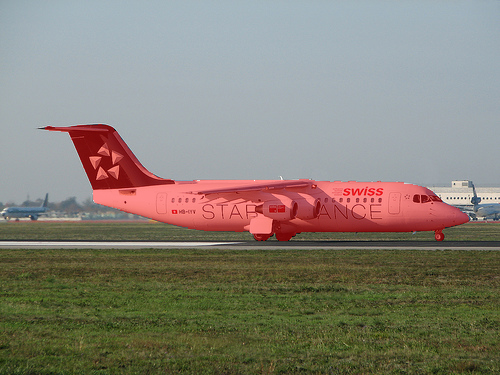

In [13]:
from seg_pipeline import overlay_from_meta

vis = overlay_from_meta(result.meta_path, alpha=0.45, color=(255, 0, 0))
display(vis)

查询原图 (左)  vs  SAM3 输出掩码 (右):


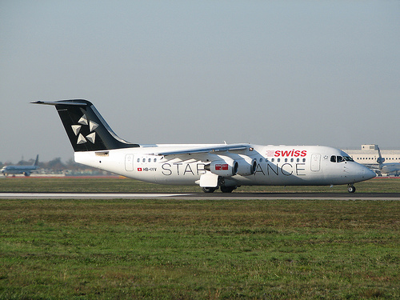

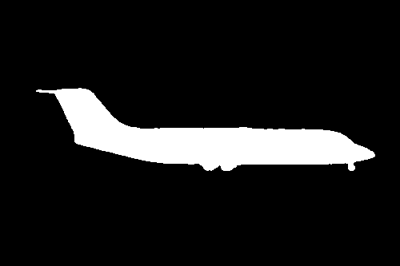

===== 元信息摘要 =====
usable Top-k  : 5
skipped        : 0
SAM3 version   : sam3
prob threshold : 0.5


In [14]:
import json
from PIL import Image
from IPython.display import display, HTML

# --- 原图 ---
query_display = Image.open(query_img).convert("RGB")
query_display.thumbnail((400, 400))

# --- 分割掩码 ---
mask_img = Image.open(result.output_mask_path)
mask_img.thumbnail((400, 400))

print("查询原图 (左)  vs  SAM3 输出掩码 (右):")
display(query_display, mask_img)

# --- 元信息摘要 ---
with open(result.meta_path, "r", encoding="utf-8") as f:
    meta = json.load(f)

print("\
===== 元信息摘要 =====")
print(f"usable Top-k  : {meta['retrieval']['usable_count']}")
print(f"skipped        : {len(meta['retrieval']['skipped'])}")
# print(f"memory locked  : {meta['memory_locked']}")
print(f"SAM3 version   : {meta['sam3_meta']['sam3']['version']}")
print(f"prob threshold : {meta['sam3_meta']['output_prob_thresh']}")

In [15]:
import numpy as np
from PIL import Image
mask = np.array(mask_img)
print(f"unique values: {np.unique(mask)}")  # 应该是 [0, 255]，不是 [0, 1, 2, ...]

unique values: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  15  16  18  19
  20  21  22  23  25  26  27  28  29  30  31  32  34  35  36  37  38  39
  40  41  42  43  45  46  48  49  50  51  52  53  54  61  62  67  68  69
  71  73  74  75  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  97  98  99 100 101 102 104 105 110 111 113 114 115
 116 117 118 119 120 122 123 124 126 127 128 130 131 132 133 136 137 138
 139 140 143 144 146 148 149 150 151 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 168 170 173 174 175 177 178 180 185 188 189 191 192
 193 194 195 196 197 198 199 200 201 203 204 206 207 208 209 211 213 214
 215 216 217 218 219 222 223 224 225 226 227 228 229 230 231 232 235 238
 239 240 241 242 243 244 245 246 247 248 249 250 251 252 253 254 255]


## 6. （可选）索引持久化与复用

RAG 索引已持久化到 `RAG_INDEX_DIR`。下次使用时可直接加载，无需重新导入数据集：

```python
rag = RAGSystem(index_dir="./voc2012_rag_index")
topk = rag.search(query_image=query_img, k=5)
```